## Logistic Regression 

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data:

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
pumpkins = pd.read_csv(r"C:\Users\Nada\Documents\IEEE-CS-DataScience-26\Task-22\US-pumpkins.csv")


In [8]:
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [9]:
new_columns = ['Color', 'Origin', 'Item Size', 'Variety', 'City Name', 'Package']
pumpkins = pumpkins[new_columns]

pumpkins.dropna(inplace=True)

# Let's have a look to our data!

By visualising it with Seaborn

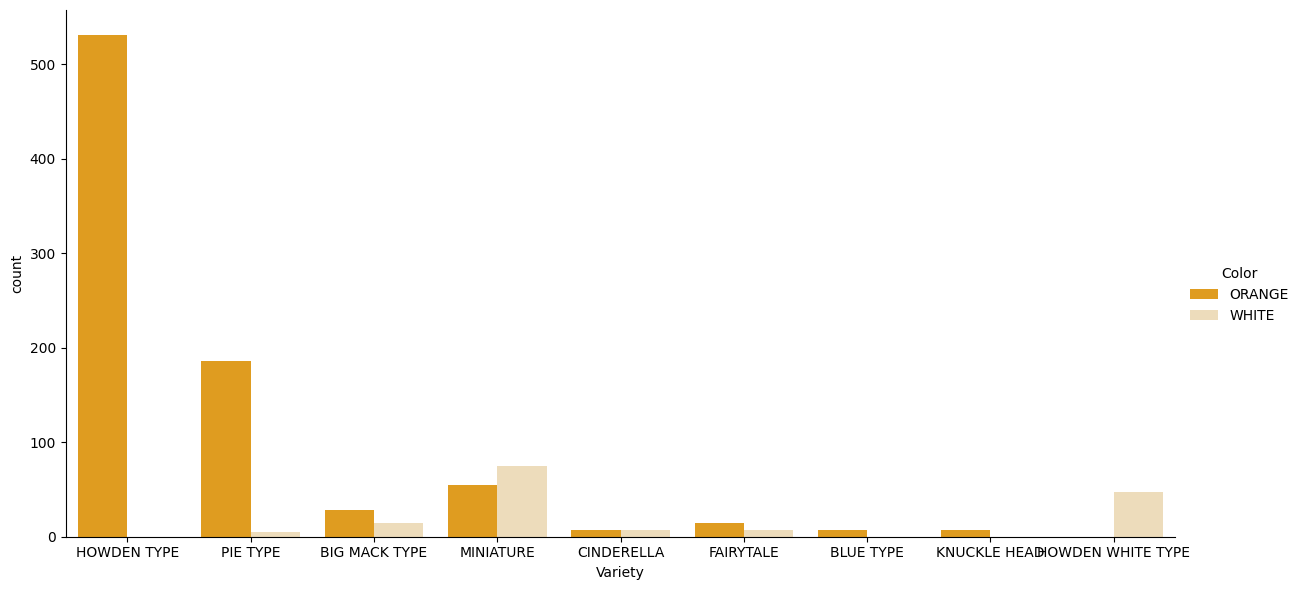

In [12]:
import seaborn as sns
# Specify colors for each values of the hue variable
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat'
}
# Plot a bar plot to visualize how many pumpkins of each variety are orange or white
sns.catplot(
    data=pumpkins,
    x='Variety',
    hue='Color',
    kind='count',
    palette=palette,
     height=6,      
    aspect=2  
)

# Data pre-processing

Let's encode features and labels to better plot the data and train the model

In [13]:
# Let's look at the different values of the 'Item Size' column
pumpkins['Item Size'].value_counts()

Item Size
sml        273
lge        197
xlge       166
med        146
med-lge    100
jbo         97
exjbo       12
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import OrdinalEncoder
# Encode the 'Item Size' column using ordinal encoding
item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)
pumpkins['Item Size'] = ordinal_encoder.fit_transform(pumpkins[['Item Size']])

In [15]:
from sklearn.preprocessing import OneHotEncoder
# Encode all the other features using one-hot encoding
categorical_features = ['Origin', 'Variety', 'City Name', 'Package']

one_hot_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = one_hot_encoder.fit_transform(pumpkins[categorical_features])

one_hot_df = pd.DataFrame(
    one_hot_encoded,
    columns=one_hot_encoder.get_feature_names_out(categorical_features),
    index=pumpkins.index
)

pumpkins = pd.concat([pumpkins.drop(columns=categorical_features), one_hot_df], axis=1)

In [19]:
print(pumpkins.columns.tolist())

['Color', 'Item Size', 'Origin_ALABAMA', 'Origin_CALIFORNIA', 'Origin_CANADA', 'Origin_DELAWARE', 'Origin_ILLINOIS', 'Origin_MARYLAND', 'Origin_MASSACHUSETTS', 'Origin_MEXICO', 'Origin_MICHIGAN', 'Origin_NEW JERSEY', 'Origin_NEW YORK', 'Origin_NORTH CAROLINA', 'Origin_OHIO', 'Origin_PENNSYLVANIA', 'Origin_TENNESSEE', 'Origin_TEXAS', 'Origin_VERMONT', 'Origin_VIRGINIA', 'Variety_BIG MACK TYPE', 'Variety_BLUE TYPE', 'Variety_CINDERELLA', 'Variety_FAIRYTALE', 'Variety_HOWDEN TYPE', 'Variety_HOWDEN WHITE TYPE', 'Variety_KNUCKLE HEAD', 'Variety_MINIATURE', 'Variety_PIE TYPE', 'City Name_ATLANTA', 'City Name_BALTIMORE', 'City Name_BOSTON', 'City Name_CHICAGO', 'City Name_COLUMBIA', 'City Name_DALLAS', 'City Name_DETROIT', 'City Name_LOS ANGELES', 'City Name_MIAMI', 'City Name_NEW YORK', 'City Name_PHILADELPHIA', 'City Name_SAN FRANCISCO', 'City Name_ST. LOUIS', 'Package_1 1/9 bushel cartons', 'Package_1 1/9 bushel crates', 'Package_1/2 bushel cartons', 'Package_24 inch bins', 'Package_36 inc

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode the target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(pumpkins['Color'])  # ORANGE=1, WHITE=0 (alphabetical)

X = pumpkins.drop(columns=['Color'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [21]:
from sklearn.preprocessing import LabelEncoder
# Encode the 'Color' column using label encoding
label_encoder = LabelEncoder()
pumpkins['Color'] = label_encoder.fit_transform(pumpkins['Color'])


In [22]:
# Let's look at the mapping between the encoded values and the original values
for i, class_label in enumerate(label_encoder.classes_):
    print(f"{i} -> {class_label}")

0 -> ORANGE
1 -> WHITE


# Analysing relationships between features and label

c:\Users\Nada\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(**kwargs)


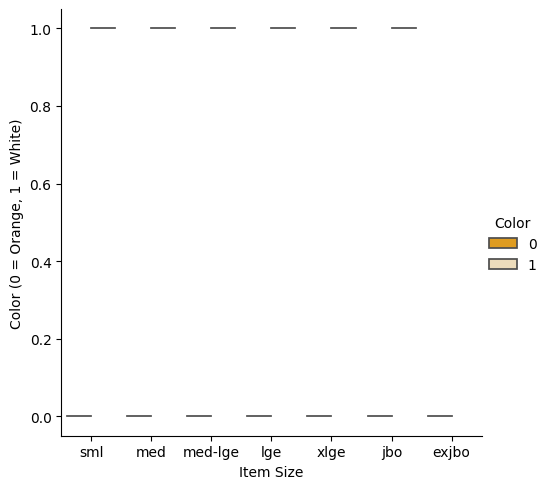

In [24]:
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}
# We need the encoded Item Size column to use it as the x-axis values in the plot
item_size_categories = ['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']

# Defining axis labels 
g = sns.catplot(
    data=pumpkins,
    x='Item Size', y='Color', hue='Color',
    kind='violin',
    palette={label_encoder.transform([label])[0]: color for label, color in palette.items()}
)
g.set(xticklabels=item_size_categories)
g.set_axis_labels('Item Size', 'Color (0 = Orange, 1 = White)')

Let's now focus on a specific relationship: Item Size and Color!

In [25]:
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

<Axes: xlabel='Color', ylabel='Item Size'>

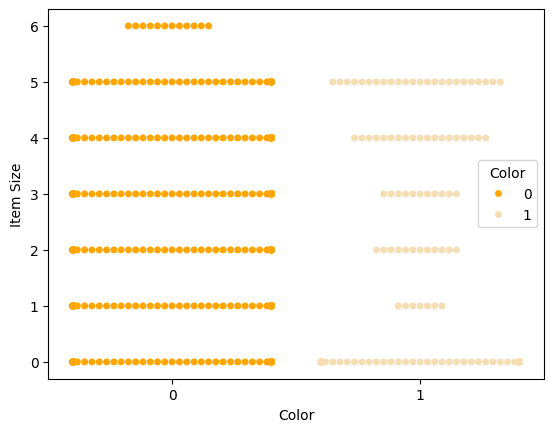

In [27]:
# Suppressing warning message claiming that a portion of points cannot be placed into the plot due to the high number of data points
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

palette = {
    0: 'orange',
    1: 'wheat'
}
sns.swarmplot(x="Color", y="Item Size", hue="Color", data=pumpkins, palette=palette)

**Watch out**: Ignoring warnings is NOT a best practice and should be avoid, whenever possible. Warnings often contain useful messages that let us improve our code and solve an issue.
The reason why we are ignoring this specific warning is to guarantee the readability of the plot. Plotting all the data points with a reduced marker size, while keeping consistency with the palette color, generates an unclear visualization.

# Build your model

In [28]:
from sklearn.model_selection import train_test_split
# X is the encoded features
X = pumpkins.drop(columns=['Color'])

# y is the encoded label
y = pumpkins['Color']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model on the pumpkin dataset
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate the model and print the results
y_pred = model.predict(X_test)

print(f"F1 score: {f1_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

F1 score: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       157
           1       0.83      0.69      0.75        42

    accuracy                           0.90       199
   macro avg       0.87      0.83      0.85       199
weighted avg       0.90      0.90      0.90       199



In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[151   6]
 [ 13  29]]
